In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
df = yf.download("^NSEI", start="2010-01-01")
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2026-05-06  24330.949219  24356.500000  23997.900391  24171.000000  429200
2026-05-07  24326.650391  24482.099609  24284.000000  24398.500000  440600
2026-05-08  24176.150391  24253.800781  24126.650391  24233.650391  335900
2026-05-11  23815.849609  23997.449219  23799.099609  23970.099609  390100
2026-05-12  23379.550781  23757.550781  23348.400391  23722.599609  447500


In [4]:
df.columns = ["Close", "High", "Low", "Open", "Volume"]


count    4014.000000
mean        0.000428
std         0.010424
min        -0.129805
25%        -0.004844
50%         0.000584
75%         0.006110
max         0.087632
Name: return, dtype: float64

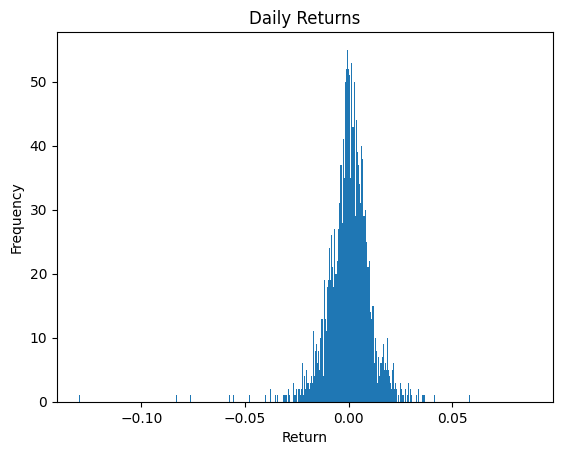

In [5]:
df["return"] = df["Close"]/df["Close"].shift(1) - 1
plt.hist(df["return"],bins=1000)
plt.title("Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
df["return"].describe()



In [6]:
df_ohlc = df["Close"].resample("ME").ohlc()
df_ohlc.describe()

,open,high,low,close
count,197.000000,197.000000,197.000000,197.000000
mean,12094.045722,12448.636815,11773.632527,12161.152795
std,6452.775191,6604.364421,6316.848995,6467.896984
min,4765.299805,4931.850098,4544.200195,4624.299805
25%,6221.450195,6363.899902,6139.049805,6304.000000
50%,10211.799805,10471.000000,9998.049805,10302.099609
75%,17340.050781,17855.099609,16887.349609,17303.949219
max,26175.750000,26328.550781,25758.000000,26202.949219


In [7]:

df_std = df["return"].groupby(df.index.year).std() * (252**0.5)
print(df_std)
print(df_std.nlargest(5))

Date
2010    0.163200
2011    0.211865
2012    0.155362
2013    0.181721
2014    0.128097
2015    0.163531
2016    0.151947
2017    0.090289
2018    0.128838
2019    0.139415
2020    0.313290
2021    0.156535
2022    0.173275
2023    0.098153
2024    0.140640
2025    0.118111
2026    0.183535
Name: return, dtype: float64
Date
2020    0.313290
2011    0.211865
2026    0.183535
2013    0.181721
2022    0.173275
Name: return, dtype: float64


Date
2020-04-07    0.087632
2020-03-25    0.066247
2020-03-20    0.058329
2019-09-20    0.053191
2021-02-01    0.047424
Name: return, dtype: float64
Date
2020-03-23   -0.129805
2020-03-12   -0.083019
2020-03-16   -0.076121
2024-06-04   -0.059294
2015-08-24   -0.059151
Name: return, dtype: float64


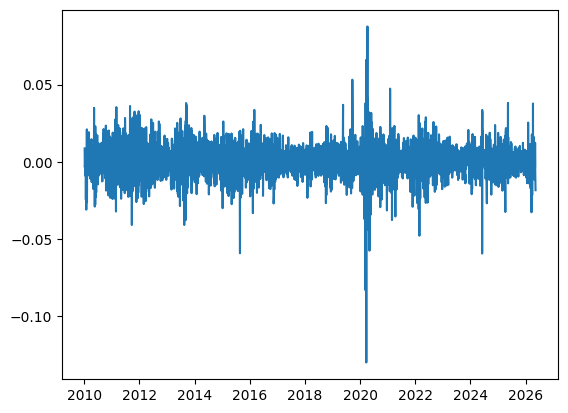

In [8]:
plt.plot(df.index, df["return"])
print(df["return"].nlargest(5))
print(df["return"].nsmallest(5))

#Observations:

1. biggest range in std was in year 2020 because of the covid pandemic.
2. anual std for each year sits around 0.15 but we have seen years with alot more than that 2020, 2011 and 2026 and its not over yet
3. It was amazing to see a simple 1% std becomes more than 15% annually thats a lot
4. it was surprsing to see that top 3 returns positive and negative to be in a single year of 2020


In [9]:
df_5yr = yf.download("^NSEI",end= "2026-05-05", start="2021-05-05")
df_5yr.columns = ['close', 'high', 'low', 'open', 'volume']
df_5yr['return'] = df_5yr['close'].pct_change()
df_5yr['actual_return'] = df_5yr['return'] * (1-0.02)
annual_return = 0.15


[*********************100%***********************]  1 of 1 completed


##Pull Nifty 50 data from yfinance. 5 years. Then:

1. Calculate daily returns
2. Estimate a realistic round-trip transaction cost — spread plus slippage — and justify your number
3. Show how many trading days per year a strategy would need to break even on costs alone if it targets 15% annual return
4. Plot annual volatility by year

[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
max days for 15% return to break even = 150.0
      Volatility              Notes
Date                               
2021    0.122788     Standard Entry
2022    0.173275     Standard Entry
2023    0.098153     Standard Entry
2024    0.140640     Standard Entry
2025    0.118111     Standard Entry
2026    0.184392  Partial Year Data


Text(0.5, 1.0, 'Annual Volatility')

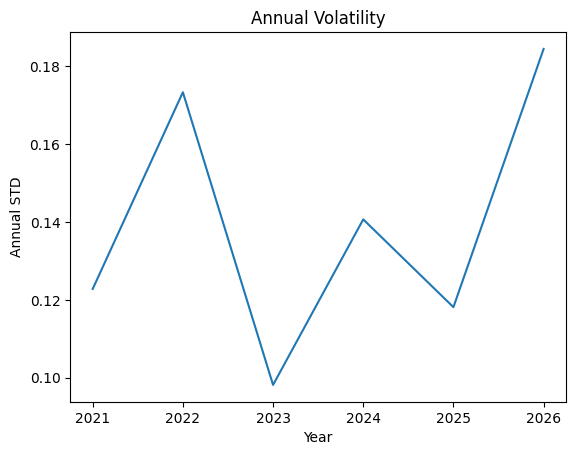

In [10]:
df_5yr = yf.download("^NSEI",end= "2026-05-05", start="2021-05-05")
df_5yr.columns = df_5yr.columns.droplevel(1)
print(df_5yr.columns)
df_5yr.columns = ['close', 'high', 'low', 'open', 'volume']
df_5yr['return'] = df_5yr['close'].pct_change() 

ret_gen = 0.15
round_trip_transaction_cost = 0.001
days = ret_gen/round_trip_transaction_cost
print(f'max days for 15% return to break even = {days}')
annual_vol = df_5yr['return'].groupby(df_5yr.index.year).std()*252**0.5
annual_vol = annual_vol.to_frame(name='Volatility')
annual_vol['Notes'] = 'Standard Entry'
annual_vol.at[2026, 'Notes'] = 'Partial Year Data' 
print(annual_vol)
plt.plot(annual_vol['Volatility'])
plt.xlabel("Year")
plt.ylabel("Annual STD")
plt.title("Annual Volatility")

In [11]:
df_5yr = yf.download("^NSEI",end= "2026-05-05", start="2021-05-05")
df_5yr.columns = df_5yr.columns.droplevel(1)
print(df_5yr.columns)
df_5yr['Return'] = df_5yr['Close'].pct_change()
daily_std = df_5yr['Return'].std()
slippage = 0.1 * 0.05 * daily_std
annual_slippage = slippage * 52
print(annual_slippage)
print(daily_std)

[*********************100%***********************]  1 of 1 completed

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
0.0022521566063720623
0.0086621407937387


In [12]:
price = 75 * 24000 #lot size = 75, nifty price = 24000
k = 0.1 #assumed
daily_std = 0.01 #calculated from the daily spot prices
vol_tra = 200000 #lower limit of volume traded from internet
vol_per = 1/vol_tra #no of lots traded/ total no of lots traded
# As we dont have any idea about ask and bif prices we will can only estimate the cost and it is generally 0.001 round trip.
spread = 0.001 * price
slippage = k * vol_per * daily_std * price
broker = 40 # one way charge is 20
stt = 0.05 / 100 * price #only charged on sell side
nse = 0.00183 / 100 * price #transaction charge

sebi = 10 * price/10000000
stamp = 0.002 * price / 100

gst = 0.18 * (broker+sebi+nse)

total = spread + slippage + broker + stt + nse + gst + sebi + stamp

percent = total/price

print(f"Per trade Cost Percent: {percent*100: .2f}%; Annual cost percent: {percent*252*100: .2f}%")


Per trade Cost Percent:  0.16%; Annual cost percent:  39.54%


In [13]:
df = yf.download("^NSEI",end= "2026-05-05", start="2001-01-01")
df.columns = df.columns.droplevel(1)
df['return'] = df['Close'].pct_change()
df['signal'] = np.where(df['return'].shift(1)>0,1,0) #1 refer to long and 0 refer to short
# We will drop first 2 rows as those has no significance here. because we cannot have a signal withpout having last days return
df['stg_return'] = np.nan
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,return,signal,stg_return
Date,,,,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0,NaN,0,NaN
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0,0.011469,0,NaN
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0,0.040946,1,NaN
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0,0.003212,1,NaN
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0,0.018957,1,NaN
...,...,...,...,...,...,...,...,...
2026-04-27,24092.699219,24130.699219,23936.199219,23945.449219,430300,0.008149,0,NaN
2026-04-28,23995.699219,24181.800781,23957.050781,24049.900391,554100,-0.004026,1,NaN
2026-04-29,24177.650391,24334.699219,24059.949219,24096.900391,531100,0.007583,0,NaN


In [14]:
for i in range(2,len(df)):
    if df.iloc[i-1, 6] == 1:
        df.iloc[i,7] = df.iloc[i,3]/df.iloc[i-1,3]-1
    else:
        df.iloc[i,7] = -(df.iloc[i,3]/df.iloc[i-1,3]-1) 

df

Price,Close,High,Low,Open,Volume,return,signal,stg_return
Date,,,,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0,NaN,0,NaN
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0,0.011469,0,NaN
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0,0.040946,1,-0.012494
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0,0.003212,1,0.040569
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0,0.018957,1,0.003823
...,...,...,...,...,...,...,...,...
2026-04-27,24092.699219,24130.699219,23936.199219,23945.449219,430300,0.008149,0,0.006436
2026-04-28,23995.699219,24181.800781,23957.050781,24049.900391,554100,-0.004026,1,-0.004362
2026-04-29,24177.650391,24334.699219,24059.949219,24096.900391,531100,0.007583,0,0.001954


In [15]:
df['trans_cost'] = float(0)
for i in range(2,len(df)):
    if df.iloc[i,6] != df.iloc[i-1,6]:
        df.iloc[i,8] = float(0.0016)
print(df.head(20))
    

Price             Close         High          Low         Open  Volume  \
Date                                                                     
2007-09-17  4494.649902  4549.049805  4482.850098  4518.450195       0   
2007-09-18  4546.200195  4551.799805  4481.549805  4494.100098       0   
2007-09-19  4732.350098  4739.000000  4550.250000  4550.250000       0   
2007-09-20  4747.549805  4760.850098  4721.149902  4734.850098       0   
2007-09-21  4837.549805  4855.700195  4733.700195  4752.950195       0   
2007-09-24  4932.200195  4941.149902  4837.149902  4837.149902       0   
2007-09-25  4938.850098  4953.899902  4878.149902  4939.100098       0   
2007-09-26  4940.500000  4980.850098  4930.350098  4937.600098       0   
2007-09-27  5000.549805  5016.399902  4942.700195  4942.700195       0   
2007-09-28  5021.350098  5055.799805  4996.450195  4996.450195       0   
2007-10-01  5068.950195  5089.299805  5001.350098  5021.500000       0   
2007-10-03  5210.799805  5261.350098  

In [16]:
df['net_return'] = df['stg_return'] - df['trans_cost']
df['cum_return'] = (df['net_return']+1).cumprod()
df

Price,Close,High,Low,Open,Volume,return,signal,stg_return,trans_cost,net_return,cum_return
Date,,,,,,,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0,NaN,0,NaN,0.0000,NaN,NaN
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0,0.011469,0,NaN,0.0000,NaN,NaN
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0,0.040946,1,-0.012494,0.0016,-0.014094,0.985906
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0,0.003212,1,0.040569,0.0000,0.040569,1.025903
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0,0.018957,1,0.003823,0.0000,0.003823,1.029825
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-27,24092.699219,24130.699219,23936.199219,23945.449219,430300,0.008149,0,0.006436,0.0000,0.006436,0.036800
2026-04-28,23995.699219,24181.800781,23957.050781,24049.900391,554100,-0.004026,1,-0.004362,0.0016,-0.005962,0.036580
2026-04-29,24177.650391,24334.699219,24059.949219,24096.900391,531100,0.007583,0,0.001954,0.0016,0.000354,0.036593


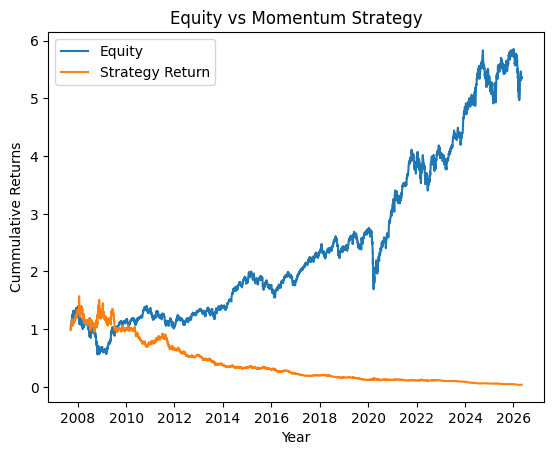

In [17]:
plt.plot((df['return']+1).cumprod(),label= 'Equity')
plt.plot(df['cum_return'], label= 'Strategy Return')
plt.xlabel('Year')
plt.ylabel('Cummulative Returns')
plt.title('Equity vs Momentum Strategy')
plt.legend()
plt.show()

In [18]:
df = yf.download("^NSEI",end= "2026-05-05", start="2001-01-01")
df.columns = df.columns.droplevel(1)
df['return'] = df['Close'].pct_change()
df_annual_mean = df['return'].groupby(df.index.year).mean()*252
df_annual = pd.DataFrame(df_annual_mean)
df_annual.columns = ['mean']
df_annual['std'] = df['return'].groupby(df.index.year).std()*252**0.5
df_annual['sharpe'] = (df_annual['mean'] - 0.065)/df_annual['std']
df_annual = df_annual.drop(2026)
df_annual['neg_std'] = df['return'].where(df['return']<0).groupby(df.index.year).std()*252**0.5
df_annual['sorinto'] = (df_annual['mean'] - 0.065)/df_annual['neg_std']
df_annual

[*********************100%***********************]  1 of 1 completed


,mean,std,sharpe,neg_std,sorinto
Date,,,,,
2007,1.156469,0.312051,3.497723,0.189672,5.754508
2008,-0.650284,0.444776,-1.608191,0.299758,-2.386203
2009,0.649383,0.348836,1.675239,0.198284,2.947200
2010,0.179682,0.162959,0.703751,0.110211,1.040570
2011,-0.271795,0.211865,-1.589670,0.116910,-2.880804
2012,0.266721,0.155362,1.298393,0.095161,2.119781
2013,0.083148,0.181721,0.099870,0.120711,0.150347
2014,0.294956,0.128097,1.795181,0.081145,2.833882
2015,-0.029402,0.163531,-0.577271,0.127906,-0.738058


In [19]:
sharpe = (df['return'].mean()*252 - 0.065) / (df['return'].std()*252**0.5)
sorinto = (df['return'].mean()*252 - 0.065) / (df['return'].where(df['return']<0).std()*252**0.5)
print(f"Sharpe Ratio: {sharpe: .2f}, Sorinto Ratio: {sorinto: .2f}")

Sharpe Ratio:  0.24, Sorinto Ratio:  0.31


In [20]:
df['peak'] = df['Close'].cummax()
df['drawdown'] = df['Close']/df['peak'] - 1


Text(0.5, 1.0, 'Drawdown at each point')

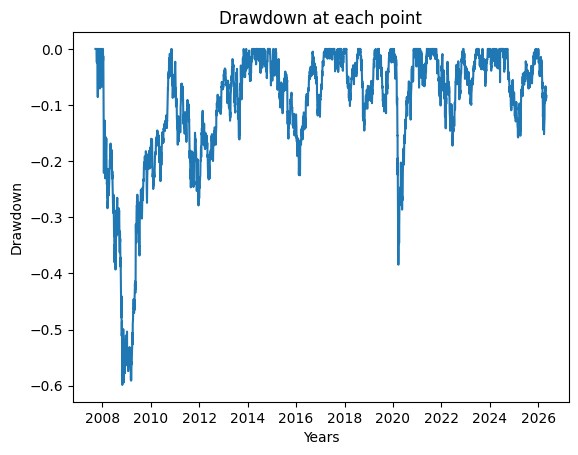

In [21]:
plt.plot(df['drawdown'])
plt.xlabel('Years')
plt.ylabel('Drawdown')
plt.title('Drawdown at each point')

In [22]:
df['drawdown'].nsmallest(5)
print(f'{df['drawdown'].idxmin().date()},{df['drawdown'].min(): .2f}')


2008-10-27,-0.60


In [23]:
df_weekly = (1+df['return']).resample('W-FRI').prod() - 1
df_weekly = pd.DataFrame(df_weekly)
df_weekly.columns = ['wk_return']
df_weekly['signal'] = np.where(df_weekly['wk_return'].shift(1)>0 , 1, -1)
df_weekly['stg_ret'] = df_weekly['wk_return'] * df_weekly['signal']
df_weekly['stg_cum'] = (1+df_weekly['stg_ret']).cumprod()
df_weekly['13wk_return'] = (df_weekly['wk_return'] + 1).rolling(13).apply(lambda x: x.prod(), raw=True) - 1
df_weekly['13wk_signal'] = np.where(df_weekly['13wk_return'].shift(1)>0 , 1, -1)
df_weekly['13wk_stg_ret'] = df_weekly['wk_return'] * df_weekly['13wk_signal']
df_weekly['13wk_stg_cum'] = (1+df_weekly['13wk_stg_ret']).cumprod()
df_weekly


,wk_return,signal,stg_ret,stg_cum,13wk_return,13wk_signal,13wk_stg_ret,13wk_stg_cum
Date,,,,,,,,
2007-09-21,0.076291,-1,-0.076291,0.923709,NaN,-1,-0.076291,0.923709
2007-09-28,0.037995,1,0.037995,0.958805,NaN,-1,-0.037995,0.888613
2007-10-05,0.032760,1,0.032760,0.990216,NaN,-1,-0.032760,0.859502
2007-10-12,0.046743,1,0.046743,1.036501,NaN,-1,-0.046743,0.819327
2007-10-19,-0.039230,1,-0.039230,0.995839,NaN,-1,0.039230,0.851469
...,...,...,...,...,...,...,...,...
2026-04-10,0.058887,-1,-0.058887,0.574755,-0.063571,-1,-0.058887,2.063590
2026-04-17,0.012596,1,0.012596,0.581995,-0.052183,-1,-0.012596,2.037596
2026-04-24,-0.018708,1,-0.018708,0.571107,-0.045939,-1,0.018708,2.075715


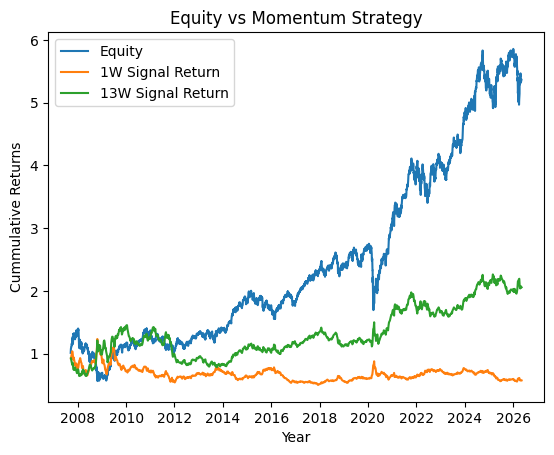

In [24]:
plt.plot((df['return']+1).cumprod(),label= 'Equity')
plt.plot(df_weekly['stg_cum'], label= '1W Signal Return')
plt.plot(df_weekly['13wk_stg_cum'], label= '13W Signal Return')
plt.xlabel('Year')
plt.ylabel('Cummulative Returns')
plt.title('Equity vs Momentum Strategy')
plt.legend()
plt.show()

In [27]:
df = yf.download("^NSEI",end= "2026-05-05", start="2001-01-01")
df.columns = df.columns.droplevel(1)
df['peak'] = df['Close'].cummax()
df['drawdown'] = df['Close']/df['peak'] - 1
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,peak,drawdown
Date,,,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0,4494.649902,0.000000
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0,4546.200195,0.000000
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0,4732.350098,0.000000
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0,4747.549805,0.000000
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0,4837.549805,0.000000
...,...,...,...,...,...,...,...
2026-04-27,24092.699219,24130.699219,23936.199219,23945.449219,430300,26328.550781,-0.084921
2026-04-28,23995.699219,24181.800781,23957.050781,24049.900391,554100,26328.550781,-0.088605
2026-04-29,24177.650391,24334.699219,24059.949219,24096.900391,531100,26328.550781,-0.081695


In [36]:
df['group'] = (df['drawdown'] < 0).astype(int).diff().ne(0).cumsum()
print(df.head(20))

Price             Close         High          Low         Open  Volume  \
Date                                                                     
2007-09-17  4494.649902  4549.049805  4482.850098  4518.450195       0   
2007-09-18  4546.200195  4551.799805  4481.549805  4494.100098       0   
2007-09-19  4732.350098  4739.000000  4550.250000  4550.250000       0   
2007-09-20  4747.549805  4760.850098  4721.149902  4734.850098       0   
2007-09-21  4837.549805  4855.700195  4733.700195  4752.950195       0   
2007-09-24  4932.200195  4941.149902  4837.149902  4837.149902       0   
2007-09-25  4938.850098  4953.899902  4878.149902  4939.100098       0   
2007-09-26  4940.500000  4980.850098  4930.350098  4937.600098       0   
2007-09-27  5000.549805  5016.399902  4942.700195  4942.700195       0   
2007-09-28  5021.350098  5055.799805  4996.450195  4996.450195       0   
2007-10-01  5068.950195  5089.299805  5001.350098  5021.500000       0   
2007-10-03  5210.799805  5261.350098  

In [87]:
df_grouped = df['drawdown'].groupby(df['group']).apply(lambda x: x.index[0])
df_grouped = pd.DataFrame(df_grouped)
df_grouped.columns = ['Start']
df_grouped['trough'] = df['drawdown'].groupby(df['group']).idxmin()
df_grouped['depth'] = abs(df['drawdown'].groupby(df['group']).min())
df_grouped['recovery_date'] = df_grouped['Start'].shift(-1)
df_grouped['recovery_time'] =  df_grouped['recovery_date'] - df_grouped['trough'] 
df_grouped['trough_time'] = df_grouped['trough'] - df_grouped['Start']
df_grouped = df_grouped[df_grouped['depth'] > 0.05 ]
df_grouped = df_grouped.sort_values(by = ['depth'], ascending= False)

df_grouped

,Start,trough,depth,recovery_date,recovery_time,trough_time
group,,,,,,
20,2008-01-09,2008-10-27,0.598559,2010-11-09,743 days,292 days
152,2020-01-15,2020-03-23,0.384399,2020-11-09,231 days,68 days
22,2010-11-10,2011-12-20,0.278876,2013-11-01,682 days,405 days
72,2015-03-04,2016-02-25,0.225166,2017-03-14,383 days,358 days
202,2021-10-19,2022-06-17,0.172298,2022-11-24,160 days,241 days
270,2024-09-27,2025-03-04,0.157667,2026-01-02,304 days,158 days
272,2026-01-05,2026-03-30,0.151818,NaT,NaT,84 days
134,2018-08-29,2018-10-26,0.145547,2019-04-16,172 days,58 days
144,2019-06-04,2019-09-19,0.114468,2019-11-27,69 days,107 days
